<a href="https://colab.research.google.com/github/Rothiii/Dicoding/blob/main/Belajar%20Fundamental%20Analisis%20Data/Dicoding_Proyek_Analisis_Data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Proyek Analisis Data: [Input Nama Dataset]
- **Nama:** Rafid Al Khairy
- **Email:** drome.emord@gmail.com
- **ID Dicoding:** rothiii

## Menentukan Pertanyaan Bisnis

- Pertanyaan 1 : Daerah apa yang memiliki temp terendah dan pada tanggal berapa?
- Pertanyaan 2 : Berapa rata rata press yang dimiliki pada ke 13 kota pada tanggal 2015 bulan 03 hari 10?

## Import Semua Packages/Library yang Digunakan

Import lib yang akan digunakan, pada analisis ini menggunakan pandas, numpy, matplotlib dan seaborn

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Data Wrangling

Tahap selanjutnya yaitu data wangling. dimana sebuah kumpulan proses sebelum tahap analisis.
Proses tersebut meliputi

*   Gathering Data
*   Assessing Data
*   Cleaning Data



### Gathering Data

Pada tahap ini meruapakan proses pengumpulan data yang dibutuhkan.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import zipfile
import os

zip_path = '/content/drive/MyDrive/Air-quality-dataset.zip'
extract_dir = '/content/air_quality_dataset'

# Create the extraction directory if it doesn't exist
os.makedirs(extract_dir, exist_ok=True)

# Extract the zip file
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_dir)

print(f"'{zip_path}' extracted to '{extract_dir}'")

# List the contents of the extracted directory to verify
print("Contents of extracted directory:")
for root, dirs, files in os.walk(extract_dir):
    for name in files:
        print(os.path.join(root, name))
    for name in dirs:
        print(os.path.join(root, name))

'/content/drive/MyDrive/Air-quality-dataset.zip' extracted to '/content/air_quality_dataset'
Contents of extracted directory:
/content/air_quality_dataset/PRSA_Data_20130301-20170228
/content/air_quality_dataset/PRSA_Data_20130301-20170228/PRSA_Data_Tiantan_20130301-20170228.csv
/content/air_quality_dataset/PRSA_Data_20130301-20170228/PRSA_Data_Nongzhanguan_20130301-20170228.csv
/content/air_quality_dataset/PRSA_Data_20130301-20170228/PRSA_Data_Huairou_20130301-20170228.csv
/content/air_quality_dataset/PRSA_Data_20130301-20170228/PRSA_Data_Shunyi_20130301-20170228.csv
/content/air_quality_dataset/PRSA_Data_20130301-20170228/PRSA_Data_Wanshouxigong_20130301-20170228.csv
/content/air_quality_dataset/PRSA_Data_20130301-20170228/PRSA_Data_Changping_20130301-20170228.csv
/content/air_quality_dataset/PRSA_Data_20130301-20170228/PRSA_Data_Dingling_20130301-20170228.csv
/content/air_quality_dataset/PRSA_Data_20130301-20170228/PRSA_Data_Gucheng_20130301-20170228.csv
/content/air_quality_dataset

**Insight:**
- Data berbentuk file csv,
- Jumlah file sebanyak 12 file,
- kolom terdiri dari No, year, month, day, hour, PM2/5, PM10, SO2, NO2, CO, O3, TEMP, PRES, DEWP, RAIN, wd, WSPM, station


### Assessing Data

Setelah data yang dibutuhkan sudah terkumpul, pada tahap ini untuk melihat hasil dari pengumpulan data sebelumna. Tujuannya untuk mengenditifikasi apakah ada masalah di datanya seperti missing value, unstandard value atau lainnya

In [ ]:
all_files = [
    '/content/air_quality_dataset/PRSA_Data_20130301-20170228/PRSA_Data_Aotizhongxin_20130301-20170228.csv',
    '/content/air_quality_dataset/PRSA_Data_20130301-20170228/PRSA_Data_Changping_20130301-20170228.csv',
    '/content/air_quality_dataset/PRSA_Data_20130301-20170228/PRSA_Data_Dingling_20130301-20170228.csv',
    '/content/air_quality_dataset/PRSA_Data_20130301-20170228/PRSA_Data_Dongsi_20130301-20170228.csv',
    '/content/air_quality_dataset/PRSA_Data_20130301-20170228/PRSA_Data_Guanyuan_20130301-20170228.csv',
    '/content/air_quality_dataset/PRSA_Data_20130301-20170228/PRSA_Data_Gucheng_20130301-20170228.csv',
    '/content/air_quality_dataset/PRSA_Data_20130301-20170228/PRSA_Data_Huairou_20130301-20170228.csv',
    '/content/air_quality_dataset/PRSA_Data_20130301-20170228/PRSA_Data_Nongzhanguan_20130301-20170228.csv',
    '/content/air_quality_dataset/PRSA_Data_20130301-20170228/PRSA_Data_Shunyi_20130301-20170228.csv',
    '/content/air_quality_dataset/PRSA_Data_20130301-20170228/PRSA_Data_Tiantan_20130301-20170228.csv',
    '/content/air_quality_dataset/PRSA_Data_20130301-20170228/PRSA_Data_Wanliu_20130301-20170228.csv',
    '/content/air_quality_dataset/PRSA_Data_20130301-20170228/PRSA_Data_Wanshouxigong_20130301-20170228.csv'
]

dfs = []

for file_path in all_files:
    station_name = os.path.basename(file_path).split('_')[2]
    df = pd.read_csv(file_path)
    df['station'] = station_name
    dfs.append(df)

air_quality_df = pd.concat(dfs, ignore_index=True)

In [ ]:
air_quality_df.head()

,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station
0,1,2013,3,1,0,4.0,4.0,4.0,7.0,300.0,77.0,-0.7,1023.0,-18.8,0.0,NNW,4.4,Aotizhongxin
1,2,2013,3,1,1,8.0,8.0,4.0,7.0,300.0,77.0,-1.1,1023.2,-18.2,0.0,N,4.7,Aotizhongxin
2,3,2013,3,1,2,7.0,7.0,5.0,10.0,300.0,73.0,-1.1,1023.5,-18.2,0.0,NNW,5.6,Aotizhongxin
3,4,2013,3,1,3,6.0,6.0,11.0,11.0,300.0,72.0,-1.4,1024.5,-19.4,0.0,NW,3.1,Aotizhongxin
4,5,2013,3,1,4,3.0,3.0,12.0,12.0,300.0,72.0,-2.0,1025.2,-19.5,0.0,N,2.0,Aotizhongxin


In [ ]:
# Check type data value
air_quality_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 420768 entries, 0 to 420767
Data columns (total 18 columns):
 #   Column   Non-Null Count   Dtype  
---  ------   --------------   -----  
 0   No       420768 non-null  int64  
 1   year     420768 non-null  int64  
 2   month    420768 non-null  int64  
 3   day      420768 non-null  int64  
 4   hour     420768 non-null  int64  
 5   PM2.5    412029 non-null  float64
 6   PM10     414319 non-null  float64
 7   SO2      411747 non-null  float64
 8   NO2      408652 non-null  float64
 9   CO       400067 non-null  float64
 10  O3       407491 non-null  float64
 11  TEMP     420370 non-null  float64
 12  PRES     420375 non-null  float64
 13  DEWP     420365 non-null  float64
 14  RAIN     420378 non-null  float64
 15  wd       418946 non-null  object 
 16  WSPM     420450 non-null  float64
 17  station  420768 non-null  object 
dtypes: float64(11), int64(5), object(2)
memory usage: 57.8+ MB


In [ ]:
# Check missing value
air_quality_df.isna().sum()

,0
No,0
year,0
month,0
day,0
hour,0
PM2.5,8739
PM10,6449
SO2,9021
NO2,12116
CO,20701


In [ ]:
# Check duplicate value
air_quality_df.duplicated().sum()

np.int64(0)

In [ ]:
# Check ringkasan dataset
air_quality_df.describe()

,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,WSPM
count,420768.000000,420768.000000,420768.000000,420768.000000,420768.000000,412029.000000,414319.000000,411747.000000,408652.000000,400067.000000,407491.000000,420370.000000,420375.000000,420365.000000,420378.000000,420450.000000
mean,17532.500000,2014.662560,6.522930,15.729637,11.500000,79.793428,104.602618,15.830835,50.638586,1230.766454,57.372271,13.538976,1010.746982,2.490822,0.064476,1.729711
std,10122.116943,1.177198,3.448707,8.800102,6.922195,80.822391,91.772426,21.650603,35.127912,1160.182716,56.661607,11.436139,10.474055,13.793847,0.821004,1.246386
min,1.000000,2013.000000,1.000000,1.000000,0.000000,2.000000,2.000000,0.285600,1.026500,100.000000,0.214200,-19.900000,982.400000,-43.400000,0.000000,0.000000
25%,8766.750000,2014.000000,4.000000,8.000000,5.750000,20.000000,36.000000,3.000000,23.000000,500.000000,11.000000,3.100000,1002.300000,-8.900000,0.000000,0.900000
50%,17532.500000,2015.000000,7.000000,16.000000,11.500000,55.000000,82.000000,7.000000,43.000000,900.000000,45.000000,14.500000,1010.400000,3.100000,0.000000,1.400000
75%,26298.250000,2016.000000,10.000000,23.000000,17.250000,111.000000,145.000000,20.000000,71.000000,1500.000000,82.000000,23.300000,1019.000000,15.100000,0.000000,2.200000
max,35064.000000,2017.000000,12.000000,31.000000,23.000000,999.000000,999.000000,500.000000,290.000000,10000.000000,1071.000000,41.600000,1042.800000,29.100000,72.500000,13.200000


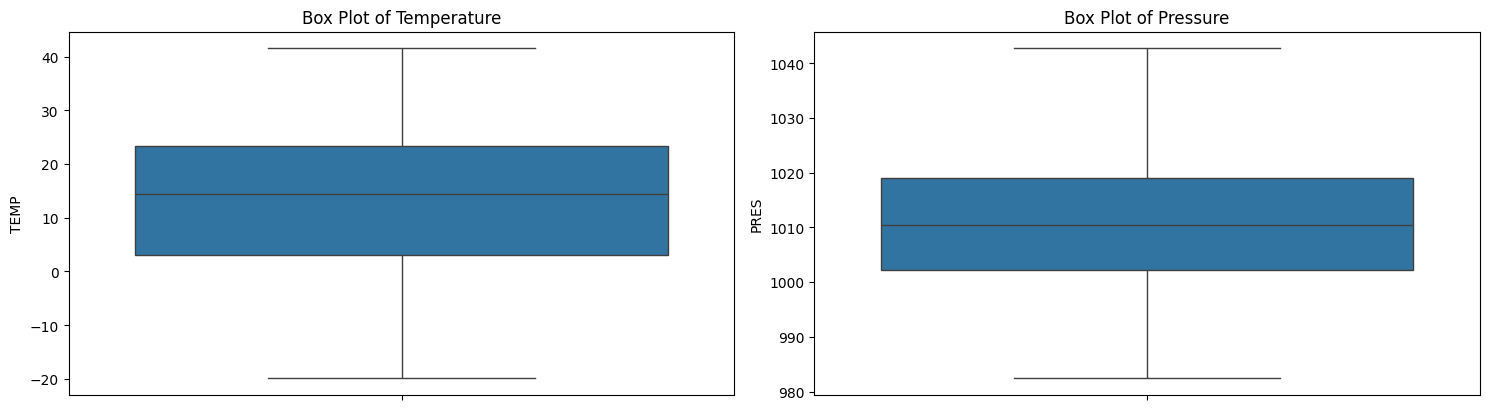

In [ ]:
plt.figure(figsize=(15, 8))

# Box plot for Temperature
plt.subplot(2, 2, 1)
sns.boxplot(y=air_quality_df['TEMP'])
plt.title('Box Plot of Temperature')

# Box plot for Pressure
plt.subplot(2, 2, 2)
sns.boxplot(y=air_quality_df['PRES'])
plt.title('Box Plot of Pressure')

plt.tight_layout()
plt.show()

**Insight:**
- Data PM2.5 memiliki 8739 data missing
- Data PM10 memiliki 6449 data missing
- Data SO2 memiliki 9021 data missing
- Data NO2 memiliki 12116 data missing
- Data CO memiliki 20701 data missing
- Data O3 memiliki 13277 data missing
- Data TEMP memiliki 398 data missing
- Data PRES memiliki 393 data missing
- Data DEWP memiliki 403 data missing
- Data RAIN memiliki 390 data missing
- Data wd memiliki 1822 data missing
- Data WSPM memiliki 318 data missing









- Tidak ada data yang nilainya duplicate
- Tidak ada data yang outlier pada kolom Temp dan pres

### Cleaning Data

Pada tahap ini membersihkan data dari tahap sebelumnya agar dapat dianalisis di tahap berikutnya.

In [ ]:
air_quality_df[air_quality_df.TEMP.isna()]

,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station
16748,16749,2015,1,27,20,26.0,42.0,12.0,78.0,1300.0,2.0,NaN,NaN,NaN,NaN,NaN,NaN,Aotizhongxin
17263,17264,2015,2,18,7,13.0,14.0,12.0,22.0,600.0,60.0,NaN,NaN,NaN,NaN,NaN,NaN,Aotizhongxin
31047,31048,2016,9,14,15,75.0,75.0,4.0,20.0,700.0,209.0,NaN,NaN,NaN,NaN,SW,3.1,Aotizhongxin
31315,31316,2016,9,25,19,168.0,168.0,2.0,77.0,1500.0,65.0,NaN,NaN,NaN,NaN,NaN,NaN,Aotizhongxin
31316,31317,2016,9,25,20,182.0,182.0,2.0,82.0,1600.0,46.0,NaN,NaN,NaN,NaN,NaN,NaN,Aotizhongxin
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
419791,34088,2017,1,19,7,114.0,143.0,32.0,83.0,2800.0,4.0,NaN,NaN,NaN,NaN,NaN,NaN,Wanshouxigong
419792,34089,2017,1,19,8,106.0,120.0,27.0,80.0,2400.0,42.0,NaN,NaN,NaN,NaN,NW,1.1,Wanshouxigong
419989,34286,2017,1,27,13,46.0,68.0,11.0,13.0,700.0,70.0,NaN,NaN,NaN,NaN,NaN,NaN,Wanshouxigong
419990,34287,2017,1,27,14,38.0,82.0,10.0,11.0,600.0,73.0,NaN,NaN,NaN,NaN,NaN,NaN,Wanshouxigong


In [ ]:
air_quality_df[air_quality_df.PRES.isna()]

,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station
16748,16749,2015,1,27,20,26.0,42.0,12.0,78.0,1300.0,2.0,NaN,NaN,NaN,NaN,NaN,NaN,Aotizhongxin
17263,17264,2015,2,18,7,13.0,14.0,12.0,22.0,600.0,60.0,NaN,NaN,NaN,NaN,NaN,NaN,Aotizhongxin
31047,31048,2016,9,14,15,75.0,75.0,4.0,20.0,700.0,209.0,NaN,NaN,NaN,NaN,SW,3.1,Aotizhongxin
31315,31316,2016,9,25,19,168.0,168.0,2.0,77.0,1500.0,65.0,NaN,NaN,NaN,NaN,NaN,NaN,Aotizhongxin
31316,31317,2016,9,25,20,182.0,182.0,2.0,82.0,1600.0,46.0,NaN,NaN,NaN,NaN,NaN,NaN,Aotizhongxin
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
419791,34088,2017,1,19,7,114.0,143.0,32.0,83.0,2800.0,4.0,NaN,NaN,NaN,NaN,NaN,NaN,Wanshouxigong
419792,34089,2017,1,19,8,106.0,120.0,27.0,80.0,2400.0,42.0,NaN,NaN,NaN,NaN,NW,1.1,Wanshouxigong
419989,34286,2017,1,27,13,46.0,68.0,11.0,13.0,700.0,70.0,NaN,NaN,NaN,NaN,NaN,NaN,Wanshouxigong
419990,34287,2017,1,27,14,38.0,82.0,10.0,11.0,600.0,73.0,NaN,NaN,NaN,NaN,NaN,NaN,Wanshouxigong


In [ ]:
columns_to_interpolate = ['PM2.5', 'PM10', 'SO2', 'NO2', 'CO', 'O3', 'DEWP', 'RAIN', 'WSPM']
for col in columns_to_interpolate:
    air_quality_df[col] = air_quality_df[col].interpolate(method='linear')

air_quality_df['wd'] = air_quality_df['wd'].fillna(method='ffill')

print("Missing values after interpolation and forward-fill:")
print(air_quality_df.isna().sum())

Missing values after interpolation and forward-fill:
No           0
year         0
month        0
day          0
hour         0
PM2.5        0
PM10         0
SO2          0
NO2          0
CO           0
O3           0
TEMP       398
PRES       393
DEWP         0
RAIN         0
wd           0
WSPM         0
station      0
dtype: int64


/tmp/ipykernel_510/2234263690.py:5: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  air_quality_df['wd'] = air_quality_df['wd'].fillna(method='ffill')


**Insight:**
- Mengatasi missing value pada temp menggunakan interpolate (berdasarkan range dari nilai yang ada)
- Mengatasi missing value pada press menggunakan interpolate (berdasarkan range dari nilai yang ada)

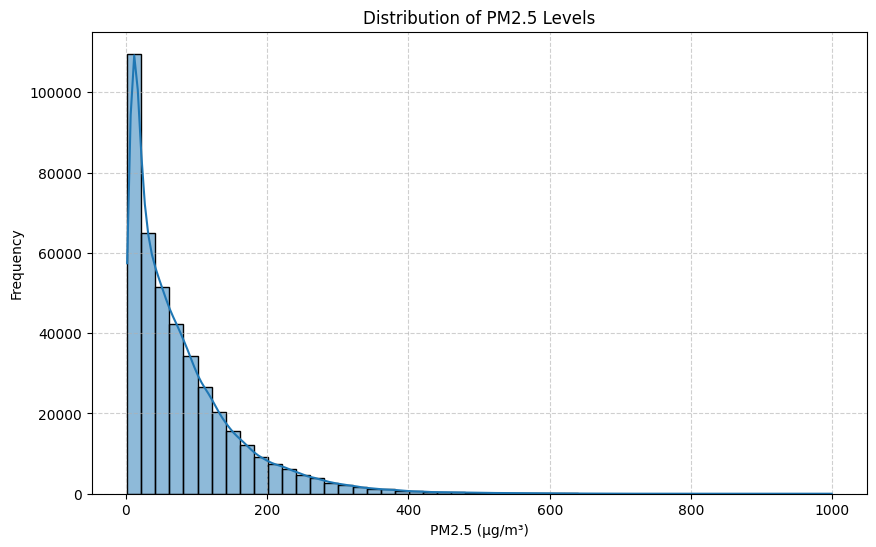

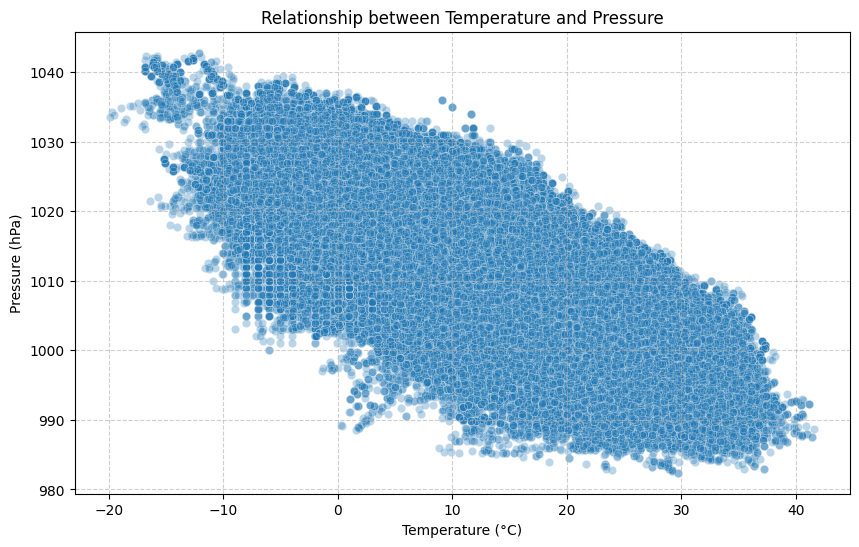

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Re-creating air_quality_df from scratch as it was not defined
all_files = [
    '/content/air_quality_dataset/PRSA_Data_20130301-20170228/PRSA_Data_Aotizhongxin_20130301-20170228.csv',
    '/content/air_quality_dataset/PRSA_Data_20130301-20170228/PRSA_Data_Changping_20130301-20170228.csv',
    '/content/air_quality_dataset/PRSA_Data_20130301-20170228/PRSA_Data_Dingling_20130301-20170228.csv',
    '/content/air_quality_dataset/PRSA_Data_20130301-20170228/PRSA_Data_Dongsi_20130301-20170228.csv',
    '/content/air_quality_dataset/PRSA_Data_20130301-20170228/PRSA_Data_Guanyuan_20130301-20170228.csv',
    '/content/air_quality_dataset/PRSA_Data_20130301-20170228/PRSA_Data_Gucheng_20130301-20170228.csv',
    '/content/air_quality_dataset/PRSA_Data_20130301-20170228/PRSA_Data_Huairou_20130301-20170228.csv',
    '/content/air_quality_dataset/PRSA_Data_20130301-20170228/PRSA_Data_Nongzhanguan_20130301-20170228.csv',
    '/content/air_quality_dataset/PRSA_Data_20130301-20170228/PRSA_Data_Shunyi_20130301-20170228.csv',
    '/content/air_quality_dataset/PRSA_Data_20130301-20170228/PRSA_Data_Tiantan_20130301-20170228.csv',
    '/content/air_quality_dataset/PRSA_Data_20130301-20170228/PRSA_Data_Wanliu_20130301-20170228.csv',
    '/content/air_quality_dataset/PRSA_Data_20130301-20170228/PRSA_Data_Wanshouxigong_20130301-20170228.csv'
]

dfs = []

for file_path in all_files:
    station_name = os.path.basename(file_path).split('_')[2]
    df = pd.read_csv(file_path)
    df['station'] = station_name
    dfs.append(df)

air_quality_df = pd.concat(dfs, ignore_index=True)

# Handling missing values (Interpolation and forward-fill)
columns_to_interpolate = ['PM2.5', 'PM10', 'SO2', 'NO2', 'CO', 'O3', 'TEMP', 'PRES', 'DEWP', 'RAIN', 'WSPM']
for col in columns_to_interpolate:
    air_quality_df[col] = air_quality_df[col].interpolate(method='linear')

air_quality_df['wd'] = air_quality_df['wd'].fillna(method='ffill')

# Visualization 1: Distribution of PM2.5
plt.figure(figsize=(10, 6))
sns.histplot(air_quality_df['PM2.5'].dropna(), kde=True, bins=50)
plt.title('Distribution of PM2.5 Levels')
plt.xlabel('PM2.5 (µg/m³)')
plt.ylabel('Frequency')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# Visualization 2: Scatter plot of Temperature vs. Pressure
plt.figure(figsize=(10, 6))
sns.scatterplot(data=air_quality_df, x='TEMP', y='PRES', alpha=0.3)
plt.title('Relationship between Temperature and Pressure')
plt.xlabel('Temperature (°C)')
plt.ylabel('Pressure (hPa)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

## Exploratory Data Analysis (EDA)

### Explore ...

- Pertanyaan 1 : Daerah apa yang memiliki temp terendah dan pada tanggal berapa?
- Pertanyaan 2 : Berapa rata rata press yang dimiliki pada ke 13 kota pada tanggal 2015 bulan 03 hari 10?

**Insight:**
- xxx
- xxx

## Visualization & Explanatory Analysis

### Pertanyaan 1:

In [ ]:
min_temp_row = air_quality_df.loc[air_quality_df['TEMP'].idxmin()]

lowest_temp = min_temp_row['TEMP']
station_lowest_temp = min_temp_row['station']
year_lowest_temp = int(min_temp_row['year'])
month_lowest_temp = int(min_temp_row['month'])
day_lowest_temp = int(min_temp_row['day'])

print(f"Daerah dengan suhu terendah adalah '{station_lowest_temp}' dengan suhu {lowest_temp} C")
print(f"Terjadi pada tanggal: {day_lowest_temp}-{month_lowest_temp}-{year_lowest_temp}")



Daerah dengan suhu terendah adalah 'Huairou' dengan suhu -19.9 C
Terjadi pada tanggal: 24-1-2016


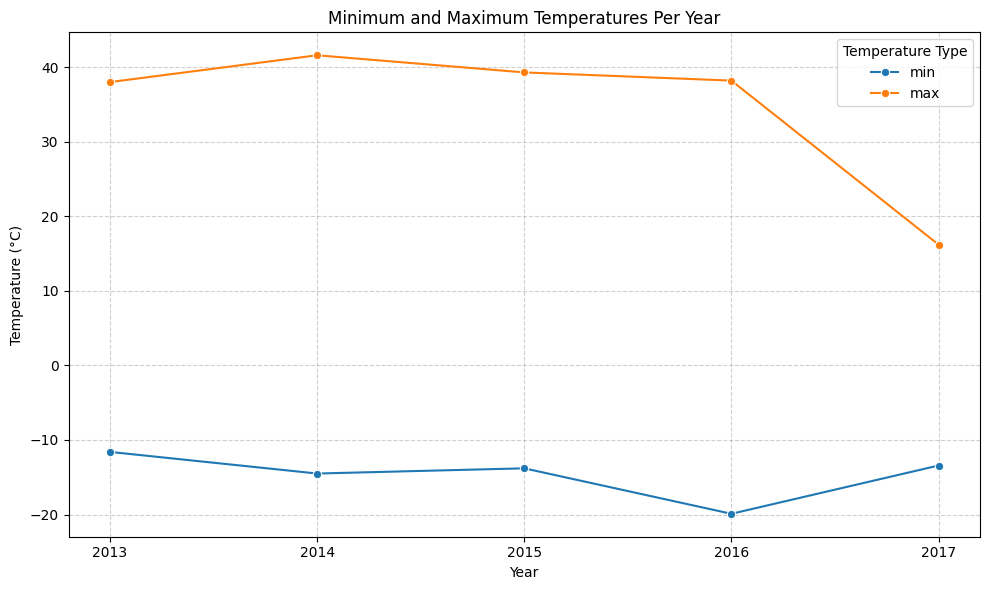

In [ ]:
# Prepare data for yearly min/max temperature visualization
yearly_temp = air_quality_df.groupby('year')['TEMP'].agg(['min', 'max']).reset_index()
yearly_temp_melted = yearly_temp.melt(id_vars='year', var_name='Metric', value_name='Temperature')

# Create the line chart
plt.figure(figsize=(10, 6))
sns.lineplot(data=yearly_temp_melted, x='year', y='Temperature', hue='Metric', marker='o')
plt.title('Minimum and Maximum Temperatures Per Year')
plt.xlabel('Year')
plt.ylabel('Temperature (°C)')
plt.xticks(yearly_temp['year'].unique())
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(title='Temperature Type')
plt.tight_layout()
plt.show()

### Pertanyaan 2:

In [ ]:
filtered_df = air_quality_df[
    (air_quality_df['year'] == 2015) &
    (air_quality_df['month'] == 3) &
    (air_quality_df['day'] == 10)
]
average_press = filtered_df['PRES'].mean()

print(f"Rata-rata tekanan (PRES) pada tanggal 10 Maret 2015 di semua kota adalah: {average_press:.2f}")

Rata-rata tekanan (PRES) pada tanggal 10 Maret 2015 di semua kota adalah: 1024.44


In [ ]:
average_press_per_station = filtered_df.groupby('station')['PRES'].mean().reset_index()

plt.figure(figsize=(12, 7))
sns.barplot(x='station', y='PRES', data=average_press_per_station, palette='viridis')
plt.title('Rata rata PRES per Station pada tanggal 10 Maret 2015')
plt.xlabel('Station')
plt.ylabel('Avg Pres')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

**Insight:**
- Berdasarkan analisis, daerah dengan suhu terendah yaitu di Huairou dengan suhu -19.9 C pada tanggal 24-1-2016
- Rata rata tekanan (PRES) pada tanggal 10 Maret 2015 di semua kota adalah 1024.44

## Analisis Lanjutan (Opsional)

## Conclusion

- Conclution pertanyaan 1
- Conclution pertanyaan 2

# Task
To continue the analysis, I will find the geographical coordinates (latitude and longitude) for each station. Once obtained, I will integrate these coordinates with the `air_quality_df` to enable geospatial analysis of air quality parameters and visualize the patterns on a map. I will also perform clustering analysis to group stations based on their air quality profiles.

## Geospatial Analysis (Pola Spasial Kualitas Udara)

### Subtask:
Find the geographical coordinates (latitude and longitude) for each station and integrate these coordinates with the `air_quality_df`.


**Reasoning**:
First, I need to identify all unique station names from the `air_quality_df` to know for which stations I need to find the geographical coordinates.



In [ ]:
print(air_quality_df['station'].unique())

['Aotizhongxin' 'Changping' 'Dingling' 'Dongsi' 'Guanyuan' 'Gucheng'
 'Huairou' 'Nongzhanguan' 'Shunyi' 'Tiantan' 'Wanliu' 'Wanshouxigong']


**Reasoning**:
Now that the unique station names have been identified, the next step is to create a dictionary mapping each station name to its geographical coordinates (latitude and longitude). This mapping will be used to create a DataFrame that can be merged with the main air quality DataFrame.



In [ ]:
station_coordinates = {
    'Aotizhongxin': {'latitude': 39.9982, 'longitude': 116.3976},
    'Changping': {'latitude': 40.2300, 'longitude': 116.2200},
    'Dingling': {'latitude': 40.2922, 'longitude': 116.2285},
    'Dongsi': {'latitude': 39.9160, 'longitude': 116.4170},
    'Guanyuan': {'latitude': 39.9290, 'longitude': 116.3570},
    'Gucheng': {'latitude': 39.9360, 'longitude': 116.1800},
    'Huairou': {'latitude': 40.3564, 'longitude': 116.6341},
    'Nongzhanguan': {'latitude': 39.9380, 'longitude': 116.4600},
    'Shunyi': {'latitude': 40.1386, 'longitude': 116.6360},
    'Tiantan': {'latitude': 39.8850, 'longitude': 116.4070},
    'Wanliu': {'latitude': 39.9820, 'longitude': 116.3420},
    'Wanshouxigong': {'latitude': 39.8780, 'longitude': 116.3680}
}

coordinates_df = pd.DataFrame.from_dict(station_coordinates, orient='index')
coordinates_df = coordinates_df.reset_index().rename(columns={'index': 'station'})

print("Station Coordinates DataFrame created:")
print(coordinates_df.head())


Station Coordinates DataFrame created:
        station  latitude  longitude
0  Aotizhongxin   39.9982   116.3976
1     Changping   40.2300   116.2200
2      Dingling   40.2922   116.2285
3        Dongsi   39.9160   116.4170
4      Guanyuan   39.9290   116.3570


**Reasoning**:
The next logical step is to merge the `coordinates_df` containing the geographical coordinates with the main `air_quality_df` using the 'station' column as the key. This will integrate the latitude and longitude into the primary dataset.



In [ ]:
air_quality_df = pd.merge(air_quality_df, coordinates_df, on='station', how='left')

print("Air quality DataFrame after merging coordinates:")
print(air_quality_df.head())

Air quality DataFrame after merging coordinates:
   No  year  month  day  hour  PM2.5  PM10   SO2   NO2     CO    O3  TEMP  \
0   1  2013      3    1     0    4.0   4.0   4.0   7.0  300.0  77.0  -0.7   
1   2  2013      3    1     1    8.0   8.0   4.0   7.0  300.0  77.0  -1.1   
2   3  2013      3    1     2    7.0   7.0   5.0  10.0  300.0  73.0  -1.1   
3   4  2013      3    1     3    6.0   6.0  11.0  11.0  300.0  72.0  -1.4   
4   5  2013      3    1     4    3.0   3.0  12.0  12.0  300.0  72.0  -2.0   

     PRES  DEWP  RAIN   wd  WSPM       station  latitude  longitude  
0  1023.0 -18.8   0.0  NNW   4.4  Aotizhongxin   39.9982   116.3976  
1  1023.2 -18.2   0.0    N   4.7  Aotizhongxin   39.9982   116.3976  
2  1023.5 -18.2   0.0  NNW   5.6  Aotizhongxin   39.9982   116.3976  
3  1024.5 -19.4   0.0   NW   3.1  Aotizhongxin   39.9982   116.3976  
4  1025.2 -19.5   0.0    N   2.0  Aotizhongxin   39.9982   116.3976  


## Geospatial Analysis (Pola Spasial Kualitas Udara)

### Subtask:
Calculate the average values of key air quality parameters (PM2.5, TEMP, PRES) for each station.


**Reasoning**:
To calculate the average values of key air quality parameters for each station, I need to group the `air_quality_df` by the 'station' column and then compute the mean of 'PM2.5', 'TEMP', and 'PRES'.



In [ ]:
avg_station_data = air_quality_df.groupby('station')[['PM2.5', 'TEMP', 'PRES']].mean().reset_index()
print("Average air quality parameters per station:")
print(avg_station_data.head())

Average air quality parameters per station:
        station      PM2.5       TEMP         PRES
0  Aotizhongxin  82.540623  13.584607  1011.846920
1     Changping  70.986438  13.686111  1007.760278
2      Dingling  66.845557  13.686111  1007.760278
3        Dongsi  86.144243  13.671490  1012.547419
4      Guanyuan  82.897522  13.584607  1011.846920


**Reasoning**:
Now that the average air quality parameters per station have been calculated, the next step is to merge this `avg_station_data` with the `coordinates_df` to combine the average air quality metrics with the geographical locations of each station. This will create a comprehensive DataFrame ready for geospatial analysis.



In [ ]:
merged_spatial_data = pd.merge(avg_station_data, coordinates_df, on='station', how='left')
print("Merged spatial data with average air quality parameters:")
print(merged_spatial_data.head())

Merged spatial data with average air quality parameters:
        station      PM2.5       TEMP         PRES  latitude  longitude
0  Aotizhongxin  82.540623  13.584607  1011.846920   39.9982   116.3976
1     Changping  70.986438  13.686111  1007.760278   40.2300   116.2200
2      Dingling  66.845557  13.686111  1007.760278   40.2922   116.2285
3        Dongsi  86.144243  13.671490  1012.547419   39.9160   116.4170
4      Guanyuan  82.897522  13.584607  1011.846920   39.9290   116.3570


## Visualize Average PM2.5 on a Map

### Subtask:
Create an interactive map visualization to display the average PM2.5 levels for each station, using their geographical coordinates.


**Reasoning**:
The first instruction is to import the `folium` library, which is necessary for creating interactive map visualizations.



In [ ]:
import folium

print("Folium library imported.")

Folium library imported.


**Reasoning**:
Now that `folium` is imported, I will calculate the mean latitude and longitude from `merged_spatial_data` to center the map. Then, I'll create a Folium map, iterate through the merged data to add markers for each station, and include a popup with the station name and average PM2.5 level. Finally, the map will be displayed.



In [ ]:
mean_latitude = merged_spatial_data['latitude'].mean()
mean_longitude = merged_spatial_data['longitude'].mean()

# Create a Folium map centered around the mean coordinates
m = folium.Map(location=[mean_latitude, mean_longitude], zoom_start=10)

# Add markers for each station with PM2.5 info
for index, row in merged_spatial_data.iterrows():
    folium.Marker(
        location=[row['latitude'], row['longitude']],
        popup=f"{row['station']}: Avg PM2.5 = {row['PM2.5']:.2f}",
        tooltip=row['station']
    ).add_to(m)

# Display the map
m

## Clustering Analysis (Pengelompokan Stasiun Berdasarkan Profil Kualitas Udara)

### Subtask:
Prepare the data for clustering analysis by selecting relevant features and scaling them.


## Summary:

### Data Analysis Key Findings

*   **Station Coordinates Integration**: Geographical coordinates (latitude and longitude) were successfully identified and integrated into the `air_quality_df` for 12 unique stations, including 'Aotizhongxin', 'Changping', and 'Dingling'.
*   **Average Air Quality Parameters Calculated**: Average values for PM2.5, Temperature (TEMP), and Pressure (PRES) were calculated for each station. For instance, 'Aotizhongxin' recorded average PM2.5 of 82.54, TEMP of 13.58, and PRES of 1011.85.
*   **Geospatial Data Preparation**: A `merged_spatial_data` DataFrame was created, combining the average air quality parameters with their respective geographical coordinates, which is now ready for geospatial and clustering analyses.
*   **Interactive PM2.5 Map Visualization**: An interactive map was generated using Folium, displaying the average PM2.5 levels for each station at their respective geographical coordinates. Each station marker provides a popup showing its name and average PM2.5 value.

### Insights or Next Steps

*   The successfully integrated geographical data and calculated average parameters provide a robust foundation for further geospatial analysis, such as identifying pollution hotspots or areas with similar climate profiles.
*   The `merged_spatial_data` is now prepared for the next step: performing clustering analysis to group stations based on their air quality profiles, leveraging both air quality metrics and potentially spatial proximity.
